<a href="https://colab.research.google.com/github/EcoCommonsAustralia/notebooks/blob/zhaoxiangmax-patch-1/converting_shapefile_to_geotiff_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/notebooks_banner_withframe.png)

# Converting Shapefile (.shp) to GeoTIFF (.tif) Format

Author details: Dr Ryan Newis

Editor details: Xiang Zhao

Contact details: support\@ecocommons.org.au

Copyright statement: This script is the product of the EcoCommons platform. Please refer to the EcoCommons website for more details: <https://www.ecocommons.org.au/>

Date: Feb 2026

# Script and Data Information

This notebook provides a simple, reproducible example of converting a shapefile (.shp) into a GeoTIFF raster (.tif) format using the `terra` package in R. It is intended as a lightweight template that can be adapted to other vector-based spatial datasets and workflows requiring raster outputs.

# Introduction

Vector and raster data represent two fundamental spatial data formats. Vector datasets (e.g. shapefile) describe spatial features as points, lines, or polygons, while raster datasets (e.g. GeoTIFF) represent information as a regular grid of cells. In many ecological and environmental workflows, it is necessary to convert vector features into raster format to support modelling, spatial prediction, or grid-based analysis.

Although format conversion is often treated as a straightforward technical step, preserving spatial metadata during this process is essential. Changes to the coordinate reference system (CRS), spatial extent, or grid resolution can introduce subtle spatial misalignment that may not be immediately visible but can affect downstream analyses and modelling results.

This notebook demonstrates a structured and transparent approach to converting a shapefile (.shp) to a GeoTIFF (.tif) raster while explicitly verifying that key spatial properties including CRS, spatial extent, and resolution are preserved during conversion. By incorporating validation steps into the workflow, the notebook promotes reproducibility and safeguards spatial data integrity.

# Key Concepts

## K.1 Vector data structure

Vector datasets represent discrete spatial features as points, lines, or polygons. Each feature can contain associated attribute information stored in a tabular format. Shapefiles (.shp) are a widely used vector format in environmental and ecological analysis.

## K.2 Raster data structure

Raster datasets represent spatial information as a grid of regularly spaced cells. Each cell contains a value corresponding to a measured or modelled variable. Raster formats such as GeoTIFF (.tif) are commonly used for spatial modelling and continuous surface analysis.

## K.3 Vector-to-raster conversion (rasterisation)

Rasterisation involves converting vector features into a grid-based raster structure. During this process, vector geometries are assigned values to raster cells based on spatial overlap and a chosen attribute field. This transformation enables vector-derived information to be integrated into raster-based modelling and analysis workflows.

# Objectives

1.  Demonstrate how to read a shapefile (.shp) into R as a SpatVector using the `terra` package.
2.  Perform a basic visual check (plot) to confirm that the shapefile has been loaded correctly.
3.  Convert the input polygon shapefile to a GeoTIFF (.tif) raster format and save the output while preserving the original file naming.
4.  Verify that key spatial metadata (CRS, extent, and resolution) are preserved during the conversion process.

# Workflow Overview

This notebook follows a simple, linear workflow to convert a Shapefile to a GeoTIFF raster format via the following steps:

-   Step 1: Set up the R environment and load the required package (`terra`).
-   Step 2: Define and validate the file path to the input shapefile (.shp).
-   Step 3: Read the shapefile into R as a SpatVector object and confirm that a valid CRS is defined.
-   Step 4: Perform a visual check by plotting the input vector layer.
-   Step 5: Rasterise the vector layer and write the resulting dataset to disk as a GeoTIFF (.tif), preserving the original file name and providing a transparent output location.
-   Step 6: Validate that CRS, spatial extent, and resolution are preserved.

In the near future, this material may form part of comprehensive support materials available to EcoCommons users. If you have any corrections or suggestions to improve the efficiency, please [contact the EcoCommons](mailto:support@ecocommons.org.au) team.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)

# Step 1. Install and load required packages

Install and load R packages that are not present in the work environment. For this notebook, only the `terra` package is required for the shapefile (.shp) to GeoTIFF (.tif) conversion and `googledrive` to download the example shapefile.


In [ ]:

# Install and load required packages (if not already installed)
required_packages <- c(
  "terra",
  "googledrive"
)

for (pkg in required_packages) {

  # Install if missing
  if (!pkg %in% installed.packages()[, "Package"]) {
    install.packages(pkg)
    cat("Package installed successfully:", pkg, "\n")
  }

  # Load quietly
  suppressPackageStartupMessages(
    library(pkg, character.only = TRUE)
  )

  cat("Package loaded successfully:", pkg, "\n")
}


Package loaded successfully: terra 
Package loaded successfully: googledrive 



# Step 2. Define the path to the input shapefile (.shp)

We have provided an example shapefile (.shp) for this notebook via OPTION 2 – Google Drive. If you would like to use your own shapefile, choose OPTION 1, commenting out this line:

`shp_file <- NULL`

and uncomment this line with your updated path:

`shp_file <- "/path_to_your_file"`

The example shapefile is a based off a binary prediction of suitable habitat for a modelled bird species.

Note: The input Shapefile must:

-   Include all required component files (.shp, .shx, .dbf, and .prj) in the same folder.
-   Contain at least one numeric attribute field (used for rasterisation).
-   Have a valid Coordinate Reference System (CRS) defined.

If the shapefile does not contain CRS information, or does not include a numeric attribute field, the conversion to raster will stop.


In [ ]:

# OPTION 1: User-defined local Shapefile
shp_file <- NULL
#shp_file <- "/path_to_your_file"


# OPTION 2: Download example Shapefile if no local file
if (is.null(shp_file)) {

  drive_deauth()

  workspace <- getwd()
  datafolder_path <- file.path(workspace, "data")

  if (!dir.exists(datafolder_path)) {
    dir.create(datafolder_path, recursive = TRUE)
  }

  # Google Drive folder containing ALL shapefile components
  folder_id <- "1RWM7SOJYOpdBNvROIeCjDc2nxn_Cjr7W"

  # List files in folder
  files <- drive_ls(as_id(folder_id))

  # Download all files in folder
  for (i in seq_len(nrow(files))) {
    drive_download(
      files$id[i],
      path = file.path(datafolder_path, files$name[i]),
      overwrite = TRUE
    )
  }

  # Define shapefile path (must match .shp filename exactly)
  shp_file <- file.path(datafolder_path, "example_binary_prediction_sf.shp")
}

# Final safety check
if (!file.exists(shp_file)) {
  stop("Input Shapefile file not found.")
}

# Extract base file name (used downstream)
base_name <- tools::file_path_sans_ext(basename(shp_file))


File downloaded:

• example_binary_prediction_sf.shp <id: 1qGCytOsWF-e1lSCW-xQzsWVyguY7VTMs>

Saved locally as:

• /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/example_binary_prediction_sf.shp

File downloaded:

• example_binary_prediction_sf.dbf <id: 1J70mowdBm04b_MjWmM_UGT4Va0oZAY-w>

Saved locally as:

• /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/example_binary_prediction_sf.dbf

File downloaded:

• example_binary_prediction_sf.cpg <id: 15oJXob7GYY-MOnk6r9cOKRZvSeWVECUp>

Saved locally as:

• /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/example_binary_prediction_sf.cpg

File downloaded:

• example_binary_prediction_sf.prj <id: 120-7FczdqN8wJecR_YcpYa1KxBsvpnJ6>

Saved locally as:

• /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/example_binary_prediction_sf.prj

File downloaded:

• example_binary_prediction_sf.shx <id: 19Cov1jhAXGy4_FDb6lzx6dyIsZvhKd3D>

Saved locally as:

• /Users/xiangzhaoqcif/dev/notebooks_zh


# Step 3. Read shapefile (.shp) into R

The vect() function reads the shapefile (.shp) into R as a SpatVector object. This step confirms that the vector dataset can be successfully loaded and that a valid coordinate reference system (CRS) is defined before proceeding with rasterisation.


In [ ]:

# Read the shapefile into R as a SpatVector object
input_vector <- vect(shp_file)

cat("CRS of input vector:\n")
print(crs(input_vector))

# Stop if CRS is missing
if (is.na(crs(input_vector)) || crs(input_vector) == "") {
  stop(
    "❌ Input Shapefile has NO CRS defined.\n",
    "Please ensure the file has a valid CRS before proceeding."
  )
}


CRS of input vector:
[1] "GEOGCRS[\"WGS 84\",\n    DATUM[\"World Geodetic System 1984\",\n        ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n            LENGTHUNIT[\"metre\",1]]],\n    PRIMEM[\"Greenwich\",0,\n        ANGLEUNIT[\"degree\",0.0174532925199433]],\n    CS[ellipsoidal,2],\n        AXIS[\"geodetic latitude (Lat)\",north,\n            ORDER[1],\n            ANGLEUNIT[\"degree\",0.0174532925199433]],\n        AXIS[\"geodetic longitude (Lon)\",east,\n            ORDER[2],\n            ANGLEUNIT[\"degree\",0.0174532925199433]],\n    ID[\"EPSG\",4326]]"



# Step 4. Plot shapefile

Plot the shapefile to confirm that it has been read correctly into R before proceeding with conversion. At this stage, the shapefile exists only as an in-memory SpatVector object and has not yet been converted or written to disk.


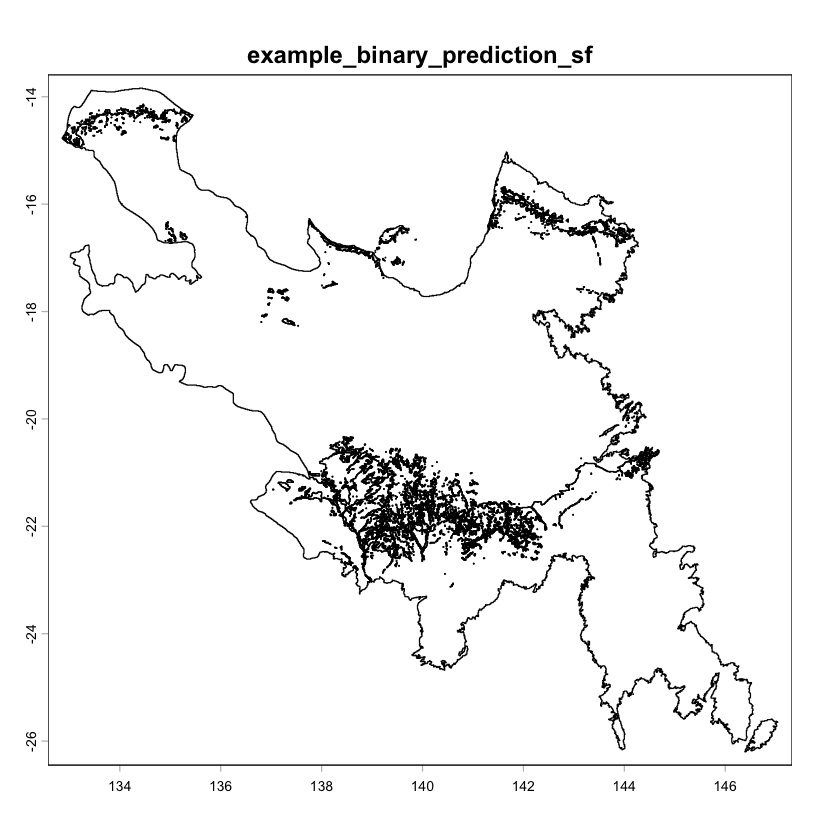

In [ ]:

plot(
  input_vector,
  col = NA,
  border = "black",
  main = base_name
)



# Step 5. Rasterise shapefile and save as GeoTIFF

Now convert the shapefile to a rsater and also save and plot the converted file. The rasterisation process assigns values from a numeric attribute field to a defined raster grid and writes the output as a GeoTIFF (.tif) file. By default, the output raster is written to the same directory as the input shapefile (.shp).


Rasterising using attribute field: notebook_s 
Raster written to:
 /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/example_binary_prediction_sf_converted.tif 


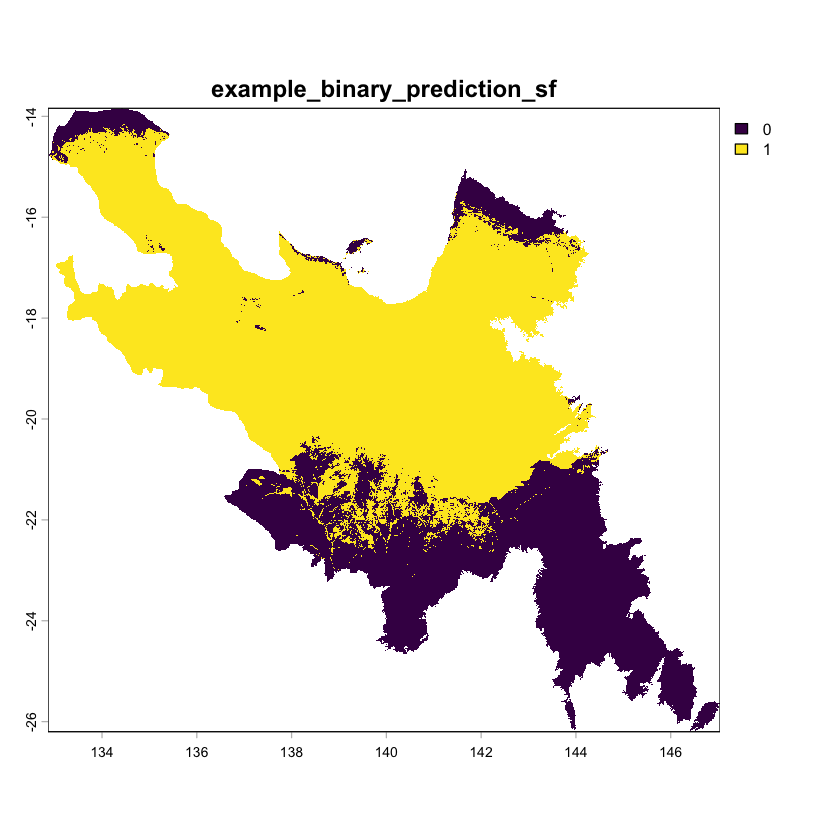

In [ ]:

# Clean and standardise attribute table
df <- values(input_vector)

for (nm in names(df)) {

  # Convert factors to character first
  if (is.factor(df[[nm]])) {
    df[[nm]] <- as.character(df[[nm]])
  }

  # Attempt numeric conversion for character columns
  if (is.character(df[[nm]])) {

    suppressWarnings({
      converted <- as.numeric(df[[nm]])
    })

    # Only keep conversion if it does NOT introduce new NA values
    if (all(is.na(df[[nm]]) == is.na(converted))) {
      df[[nm]] <- converted
    }
  }
}

# Assign cleaned attributes back
values(input_vector) <- df


# Identify numeric attribute columns
numeric_fields <- names(df)[sapply(df, is.numeric)]

if (length(numeric_fields) == 0) {
  stop(
    "❌ No numeric attribute fields found.\n",
    "Rasterisation requires a numeric field.\n",
    "Please ensure your shapefile contains at least one numeric attribute."
  )
}

# Use first numeric field
field_name <- numeric_fields[1]
cat("Rasterising using attribute field:", field_name, "\n")


# Create raster template
raster_template <- rast(
  ext(input_vector),
  resolution = 0.01,   # adjust if needed
  crs = crs(input_vector)
)


# Rasterise
output_raster <- rasterize(
  input_vector,
  raster_template,
  field = field_name,
  touches = TRUE
)

# Write output
out_dir <- dirname(shp_file)
out_file <- file.path(out_dir, paste0(base_name, "_converted.tif"))

writeRaster(
  output_raster,
  out_file,
  overwrite = TRUE,
  filetype = "GTiff"
)

cat("Raster written to:\n", out_file, "\n")

plot(output_raster, main = base_name)



# Step 6. Verify spatial metadata after writing GeoTIFF

Reload the written GeoTIFF and verify that key spatial metadata including CRS, spatial extent, and resolution have been preserved during conversion.


In [ ]:

# Reload written raster
written_raster <- rast(out_file)

# CRS check

# Extract CRS info for input vector
input_crs_info <- terra::crs(input_vector, describe = TRUE)
input_crs_name <- input_crs_info$name
input_epsg     <- input_crs_info$code

# Extract CRS info for output raster
output_crs_info <- terra::crs(written_raster, describe = TRUE)
output_crs_name <- output_crs_info$name
output_epsg     <- output_crs_info$code

cat("\nInput CRS name:", input_crs_name, "\n")
cat("Input EPSG code:", input_epsg, "\n")

cat("\nOutput CRS name:", output_crs_name, "\n")
cat("Output EPSG code:", output_epsg, "\n")

# Validate CRS
if (!same.crs(input_vector, written_raster)) {
  stop("❌ CRS mismatch detected after writing GeoTIFF.")
}

# Extent check
cat("\nInput vector extent:\n")
print(ext(input_vector))

cat("\nOutput raster extent:\n")
print(ext(written_raster))

# if (!isTRUE(all.equal(ext(input_vector), ext(written_raster)))) {
#   stop("❌ Extent mismatch detected after writing GeoTIFF.")
# }


# Resolution check
cat("\nOutput raster resolution:\n")
print(res(written_raster))

cat("\n✅ All spatial metadata successfully preserved during conversion.\n")



Input CRS name: WGS 84 
Input EPSG code: 4326 

Output CRS name: WGS 84 
Output EPSG code: 4326 

Input vector extent:
SpatExtent : 132.86, 147.04, -26.2, -13.84 (xmin, xmax, ymin, ymax)

Output raster extent:
SpatExtent : 132.86, 147.04, -26.2, -13.84 (xmin, xmax, ymin, ymax)

Output raster resolution:
[1] 0.01 0.01

✅ All spatial metadata successfully preserved during conversion.



# Summary

This notebook demonstrated a simple, reproducible workflow for converting a shapefile (.shp) into a GeoTIFF (.tif) raster using the `terra` package in R, while explicitly verifying that key spatial metadata including CRS, extent, and resolution were preserved during conversion.

A companion notebook (link below) demonstrates the reverse workflow, converting a GeoTIFF raster to shapefile format.

[Converting GeoTIFF (.tif) to Shapefile (.shp) Format](https://ecocommonsaustralia.github.io/notebook-blog/notebooks/raster_format/converting_geotiff_to_shapefile_notebook.html)

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)

EcoCommons received investment (<https://doi.org/10.3565/chbq-mr75>) from the Australian Research Data Commons (ARDC). The ARDC is enabled by the National Collaborative Research Infrastructure Strategy (NCRIS).

::: {align="center"}
**Our Partners**
:::

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/updated_ourpartner_2025.png)

## Other file formats of this notebook

| Notebook | Files | Open in Colab / ARDC Jupyter | DOI |
|:---:|:---:|:---:|:---:|
| Converting Shapefile (.shp) to GeoTIFF (.tif) Format | <a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/converting_shapefile_to_geotiff_notebook.ipynb"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/jupyter_notebook.png" width="40%"></a>&nbsp;&nbsp;<a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/converting_shapefile_to_geotiff_notebook.qmd"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/quartomd.png" width="40%"></a> | [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecocommonsaustralia/notebooks/blob/main/notebooks/converting_shapefile_to_geotiff_notebook.ipynb) | [![DOI](https://img.shields.io/badge/DOI-10.5281%2Fzenodo.19379923-blue)](https://doi.org/10.5281/zenodo.19379923) |

## How to cite this Notebook

Newis, R., & Zhao, X. Y. (2026). *Converting Shapefile (.shp) to GeoTIFF (.tif) Format* (Version 1.0) [Computational notebook]. Zenodo. <https://doi.org/10.5281/zenodo.19379923>

# How to Cite EcoCommons

If you use EcoCommons in your research, please cite the platform as follows:

> EcoCommons Australia 2026. *EcoCommons Australia – a collaborative commons for ecological and environmental modelling*, Queensland Cyber Infrastructure Foundation, Brisbane, Queensland. Available at: <https://data–explorer.app.ecocommons.org.au/> (Accessed: MM DD, YYYY). <https://doi.org/10.3565/chbq-mr75>

You can download the citation file for EcoCommons Australia here: [Download the BibTeX file](reference.bib)